### Imports

In [19]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os
import sys
from pathlib import Path
pd.reset_option("display.precision")
pd.reset_option("display.float_format")
pd.set_option("display.max_columns", None)

In [20]:
### Changing to parent directory
current_file_path = Path("").resolve()
grandparent_dir = current_file_path.parent.parent.parent
# Append this directory to the system path
sys.path.append(str(grandparent_dir))

### 1. Data

In [21]:
folder_path = os.path.join(grandparent_dir,"Raw Data - FeCN platinum 8")
filename = "CV3.dta"
file_path = os.path.join(folder_path,filename)

In [22]:
keep_cols = ["Pt","Vf", "Im"] #row number, voltage, current

with open(file_path, "r", encoding="ISO-8859-1") as f:
    content = f.readlines()
    for i,line in enumerate(content):
        if line.__contains__("CURVE"):
            index = i + 1 #finds line where datatable resides (below "CURVE" label)
            break
    content = content[index:]
        
    # Read the remaining lines and create a DataFrame
    df = pd.DataFrame([line.split('\t') for line in content if line.strip()])
    df = df.map(lambda x: x.strip() if isinstance(x, str) else x) # Remove newline characters from the last column
    df = df.drop(0, axis=1) # Drop the first column (column zero)
    df.columns = df.iloc[0] # Set the header names using the values from the first row
    df = df.drop(0) # Drop the first row (since it's now used as header)
    df = df.iloc[1:] # Drops row with units
    df = df[keep_cols]
    df["Vf"] = pd.to_numeric(df["Vf"], errors="coerce")
    df["Im"] = pd.to_numeric(df["Im"], errors="coerce")
    df = df.dropna(how='all')
    df = df.reset_index(drop=True)

#Creates a Cycle Number Column (Cycles 1-4)
df["Cycle Num"] = (df["Pt"] == "TABLE").cumsum() + 1
dfs = {}
for i in range(1,5):
    if i == 1:
        dfs[f"cycle{i}"] = df[df["Cycle Num"] ==i]
    else:
        temp_df = df[df["Cycle Num"] ==i]
        temp_df = temp_df.iloc[3:] # Drop the first row after headers are assigned
        dfs[f"cycle{i}"] = temp_df

### 2. Filtering to Stable Cycle 3

In [23]:
df_plot = dfs["cycle3"]
df_plot["Im"] = df_plot["Im"] * 10**6
df_plot

,Pt,Vf,Im,Cycle Num
2107,2101,-0.299055,-7.86044,3
2108,2102,-0.298070,-7.81824,3
2109,2103,-0.297069,-7.77991,3
2110,2104,-0.296069,-7.74429,3
2111,2105,-0.295065,-7.71009,3
...,...,...,...,...
3302,3296,-0.296053,-7.92006,3
3303,3297,-0.297032,-7.91021,3
3304,3298,-0.298046,-7.90256,3
3305,3299,-0.299042,-7.89440,3


### 3. CV Plot

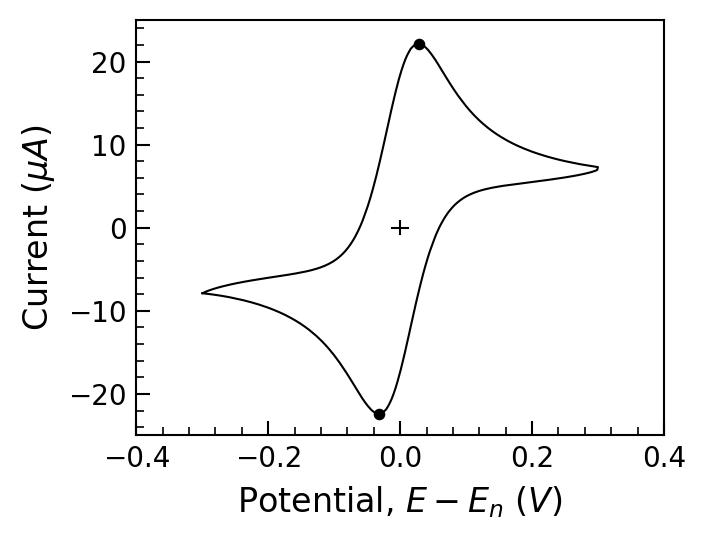

In [27]:
#Create Figure
plt.figure(figsize=(3.33,2.5),dpi=200) #7,5
ax = plt.gca()
for location in ['left', 'right', 'top', 'bottom']:
    ax.spines[location].set_linewidth(0.75)

# Plot CV
ax.plot(df_plot["Vf"], df_plot["Im"], linewidth=0.75, color="black")
idx_max = df_plot["Im"].idxmax()
idx_min = df_plot["Im"].idxmin()
x_max = df_plot.loc[idx_max, "Vf"]
y_max = df_plot.loc[idx_max, "Im"]
x_min = df_plot.loc[idx_min, "Vf"]
y_min = df_plot.loc[idx_min, "Im"]
ax.scatter([x_min,x_max], [y_min,y_max], linewidth=1, color="black",s=10) #plots min/max points

# Major locator for ticks/grid
x_axis_tick = 0.2 #x-axis tick increments
y_axis_tick = 10 #y-axis tick increments
ax.xaxis.set_major_locator(ticker.MultipleLocator(x_axis_tick))
ax.yaxis.set_major_locator(ticker.MultipleLocator(y_axis_tick))
ax.minorticks_on()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(x_axis_tick/5))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(y_axis_tick/5))
ax.tick_params(which='minor', labelbottom=False, labelleft=False, direction='in',
               length = 3, width = 0.6, color = 'black')
ax.tick_params(which='major', direction='in', labelsize=10,length=5,width=0.75)

# Axis Formatting
ax.set_xlabel(rf"Potential, $E-E_n$ ($V$)",fontsize=12)
ax.set_ylabel(rf"Current ($\mu A$)",fontsize=12)
ax.set_xlim([-0.4,0.4])
ax.set_ylim([-25,25])

# Plotting Center Cross
dx = 0.0125
ax_ratio = (ax.get_xlim()[1] - ax.get_xlim()[0]) / (ax.get_ylim()[1] - ax.get_ylim()[0])
dy = dx / ax_ratio
ax.plot([-dx, dx], [0, 0], color="black", linewidth=0.75)
ax.plot([0, 0], [-dy, dy], color="black", linewidth=0.75)

#Saving Plot
plt.tight_layout(pad=0)
plt.savefig(f"Figure1_Pt_Cycle3_CV.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()
